# 📊 Exploratory Data Analysis — Gym Exercises Dataset

Este notebook utiliza **KedroSession** para cargar datos del catálogo y genera
visualizaciones interactivas con Seaborn y Matplotlib.

**Requisito:** ejecuta primero `kedro run --pipeline=data_understanding` para
generar los datasets intermedios, o carga directamente los datos crudos.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis", font_scale=1.1)
%matplotlib inline

## 1. Carga de datos con KedroSession

In [2]:
import os, sys

# Asegurar que el directorio raíz del proyecto esté en el path
from pathlib import Path
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
project_root = str(project_root)
if os.path.join(project_root, "src") not in sys.path:
    sys.path.insert(0, os.path.join(project_root, "src"))
os.chdir(project_root)

from kedro.framework.session import KedroSession
from kedro.framework.startup import bootstrap_project
from pathlib import Path

bootstrap_project(Path(project_root))

session = KedroSession.create()
context = session.load_context()
catalog = context.catalog

print("✅ Catálogo Kedro cargado correctamente")
print(f"Datasets disponibles: {list(catalog)}")

[09/08/26 21:54:38] INFO     Using                                                                  ]8;id=10399739;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=10399740;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro/framework/project/__init__.py#302\302]8;;\
                             '/Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-pack                
                             ages/kedro/framework/project/rich_logging.yml' as logging                             
                             configuration.                                                                        

[09/08/26 21:54:38] INFO     No typed parameter requirements found, returning original   ]8;id=10399747;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro/validation/parameter_validator.py\parameter_validator.py]8;;\:]8;id=10399748;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro/validation/parameter_validator.py#124\124]8;;\
                             parameters                                                                            

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=10399755;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro_telemetry/plugin.py\plugin.py]8;;\:]8;id=10399756;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro_telemetry/plugin.py#273\273]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

✅ Catálogo Kedro cargado correctamente
Datasets disponibles: ['raw_exercises_data', 'intermediate_exercises_clean', 'eda_summary_report', 'distribution_metrics', 'intermediate_exercise_features', 'outliers_iqr_report', 'shape_statistics_report', 'correlation_matrix_report', 'parameters']


In [3]:
# Cargar el dataset crudo
raw_df = catalog.load("raw_exercises_data")
print(f"Dimensiones: {raw_df.shape}")
raw_df.head(3)

                    INFO     Loading data from raw_exercises_data (JSONDataset)...             ]8;id=10399763;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=10399764;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

Dimensiones: (1324, 15)


,id,name,category,body_part,equipment,instructions,instruction_steps,muscle_group,secondary_muscles,target,image,gif_url,media_id,created_at,attribution
0,1,3/4 sit-up,waist,waist,body weight,{'en': 'Lie flat on your back with your knees ...,{'en': ['Lie flat on your back with your knees...,hip flexors,"[hip flexors, lower back]",abs,images/0001-2gPfomN.jpg,videos/0001-2gPfomN.gif,2gPfomN,2026-03-18 12:31:32.854798+00:00,© Gym visual — https://gymvisual.com/
1,2,45° side bend,waist,waist,body weight,{'en': 'Stand with your feet shoulder-width ap...,{'en': ['Stand with your feet shoulder-width a...,obliques,[obliques],abs,images/0002-Hy9D21L.jpg,videos/0002-Hy9D21L.gif,Hy9D21L,2026-03-18 12:31:32.854953+00:00,© Gym visual — https://gymvisual.com/
2,3,air bike,waist,waist,body weight,{'en': 'Lie flat on your back with your hands ...,{'en': ['Lie flat on your back with your hands...,hip flexors,[hip flexors],abs,images/0003-1ZFqTDN.jpg,videos/0003-1ZFqTDN.gif,1ZFqTDN,2026-03-18 12:31:32.854977+00:00,© Gym visual — https://gymvisual.com/


In [4]:
# Intentar cargar el dataset limpio (requiere haber ejecutado el pipeline)
try:
    clean_df = catalog.load("intermediate_exercises_clean")
    print(f"Dataset limpio cargado: {clean_df.shape}")
except Exception:
    print("⚠️  Dataset limpio no encontrado. Ejecutando flatten manualmente...")
    from gym_exercises.pipelines.data_understanding.nodes import flatten_exercise_metadata
    clean_df = flatten_exercise_metadata(raw_df)
    print(f"Dataset aplanado: {clean_df.shape}")

clean_df.head()

                    INFO     Loading data from intermediate_exercises_clean                    ]8;id=10399769;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=10399770;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\
                             (ParquetDataset)...                                                                   

Dataset limpio cargado: (2581, 15)


,id,name,category,body_part,equipment,muscle_group,secondary_muscle,target,image,gif_url,media_id,created_at,attribution,instructions_es,instruction_steps_es_text
0,1,3/4 sit-up,waist,waist,body weight,hip flexors,hip flexors,abs,images/0001-2gPfomN.jpg,videos/0001-2gPfomN.gif,2gPfomN,2026-03-18 12:31:32.854798+00:00,© Gym visual — https://gymvisual.com/,Túmbate sobre tu espalda con las rodillas flex...,1. Túmbate sobre tu espalda con las rodillas f...
1,1,3/4 sit-up,waist,waist,body weight,hip flexors,lower back,abs,images/0001-2gPfomN.jpg,videos/0001-2gPfomN.gif,2gPfomN,2026-03-18 12:31:32.854798+00:00,© Gym visual — https://gymvisual.com/,Túmbate sobre tu espalda con las rodillas flex...,1. Túmbate sobre tu espalda con las rodillas f...
2,2,45° side bend,waist,waist,body weight,obliques,obliques,abs,images/0002-Hy9D21L.jpg,videos/0002-Hy9D21L.gif,Hy9D21L,2026-03-18 12:31:32.854953+00:00,© Gym visual — https://gymvisual.com/,Ponte de pie con los pies separados a la altur...,1. Ponte de pie con los pies separados a la al...
3,3,air bike,waist,waist,body weight,hip flexors,hip flexors,abs,images/0003-1ZFqTDN.jpg,videos/0003-1ZFqTDN.gif,1ZFqTDN,2026-03-18 12:31:32.854977+00:00,© Gym visual — https://gymvisual.com/,Túmbate sobre tu espalda con las manos colocad...,1. Túmbate sobre tu espalda con las manos colo...
4,1512,all fours squad stretch,upper legs,upper legs,body weight,hamstrings,hamstrings,quads,images/1512-qBcKorM.jpg,videos/1512-qBcKorM.gif,qBcKorM,2026-03-18 12:31:32.854997+00:00,© Gym visual — https://gymvisual.com/,"Comienza apoyado sobre manos y rodillas, con l...","1. Comienza apoyado sobre manos y rodillas, co..."


## 2. Resumen estadístico

In [5]:
# Ejercicios únicos
n_unique = clean_df["id"].nunique()
print(f"Ejercicios únicos: {n_unique}")
print(f"\nNulos por columna:")
display(clean_df.isnull().sum().to_frame("nulls").query("nulls > 0"))

print(f"\nTipos de datos:")
display(clean_df.dtypes.to_frame("dtype"))

Ejercicios únicos: 1324

Nulos por columna:


,nulls



Tipos de datos:


,dtype
id,int64
name,str
category,str
body_part,str
equipment,str
muscle_group,str
secondary_muscle,str
target,str
image,str
gif_url,str


## 3. Distribución por Body Part (Parte del cuerpo)

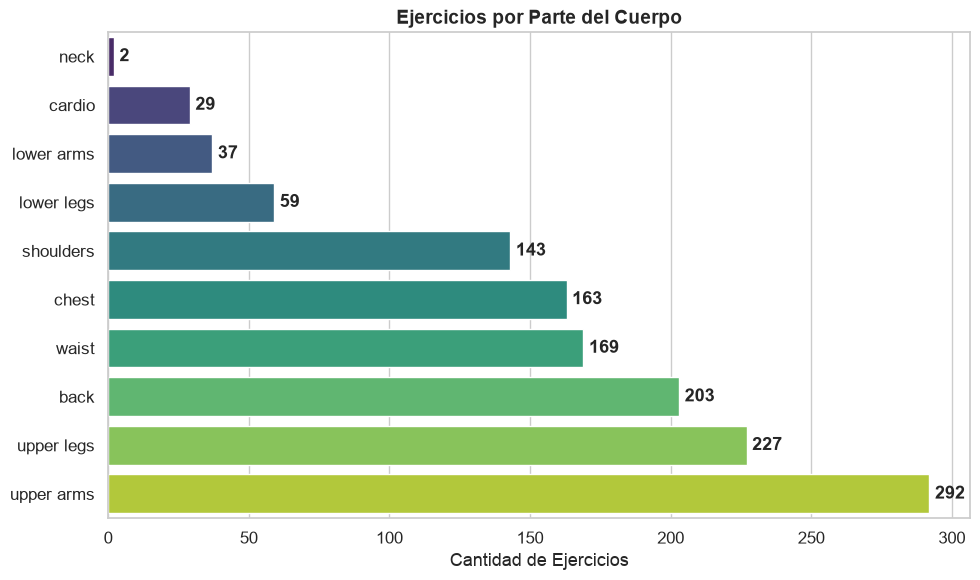

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

body_part_counts = (
    clean_df.drop_duplicates(subset=["id"])
    .groupby("body_part", as_index=False)
    .agg(count=("id", "nunique"))
    .sort_values("count", ascending=True)
)

sns.barplot(
    data=body_part_counts,
    x="count",
    y="body_part",
    hue="body_part",
    palette="viridis",
    legend=False,
    ax=ax,
)

for i, (_, row) in enumerate(body_part_counts.iterrows()):
    ax.text(row["count"] + 2, i, str(row["count"]), va="center", fontweight="bold")

ax.set_title("Ejercicios por Parte del Cuerpo", fontsize=14, fontweight="bold")
ax.set_xlabel("Cantidad de Ejercicios")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 4. Distribución por Equipment (Equipamiento)

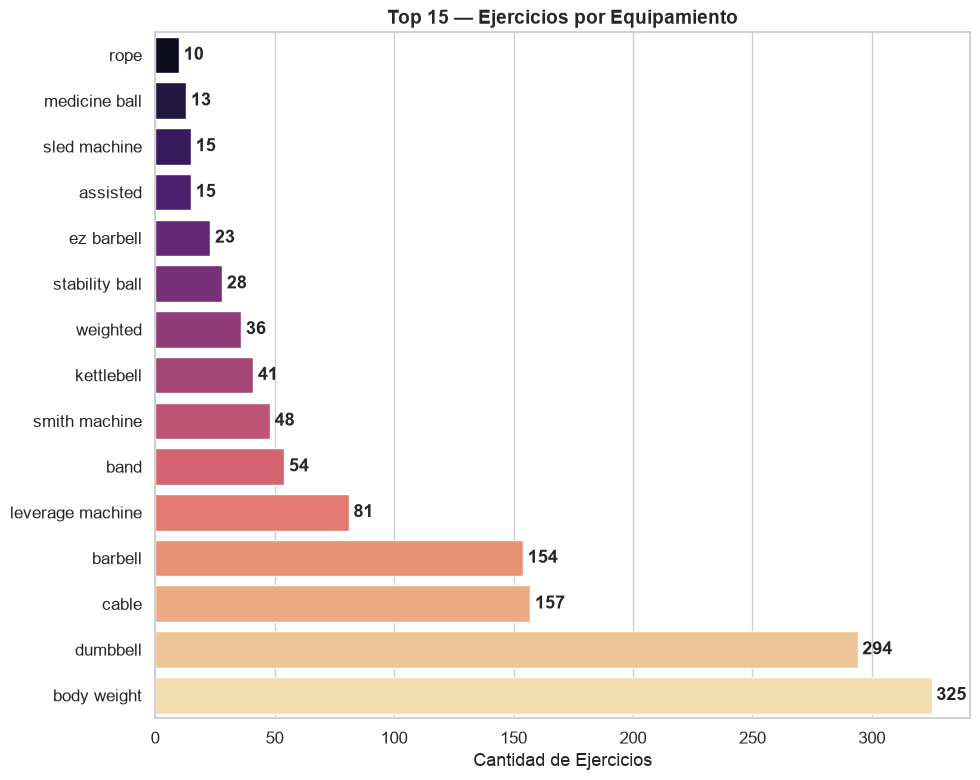

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

equip_counts = (
    clean_df.drop_duplicates(subset=["id"])
    .groupby("equipment", as_index=False)
    .agg(count=("id", "nunique"))
    .sort_values("count", ascending=True)
    .tail(15)
)

sns.barplot(
    data=equip_counts,
    x="count",
    y="equipment",
    hue="equipment",
    palette="magma",
    legend=False,
    ax=ax,
)

for i, (_, row) in enumerate(equip_counts.iterrows()):
    ax.text(row["count"] + 2, i, str(row["count"]), va="center", fontweight="bold")

ax.set_title("Top 15 — Ejercicios por Equipamiento", fontsize=14, fontweight="bold")
ax.set_xlabel("Cantidad de Ejercicios")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. Distribución por Target Muscle (Músculo objetivo)

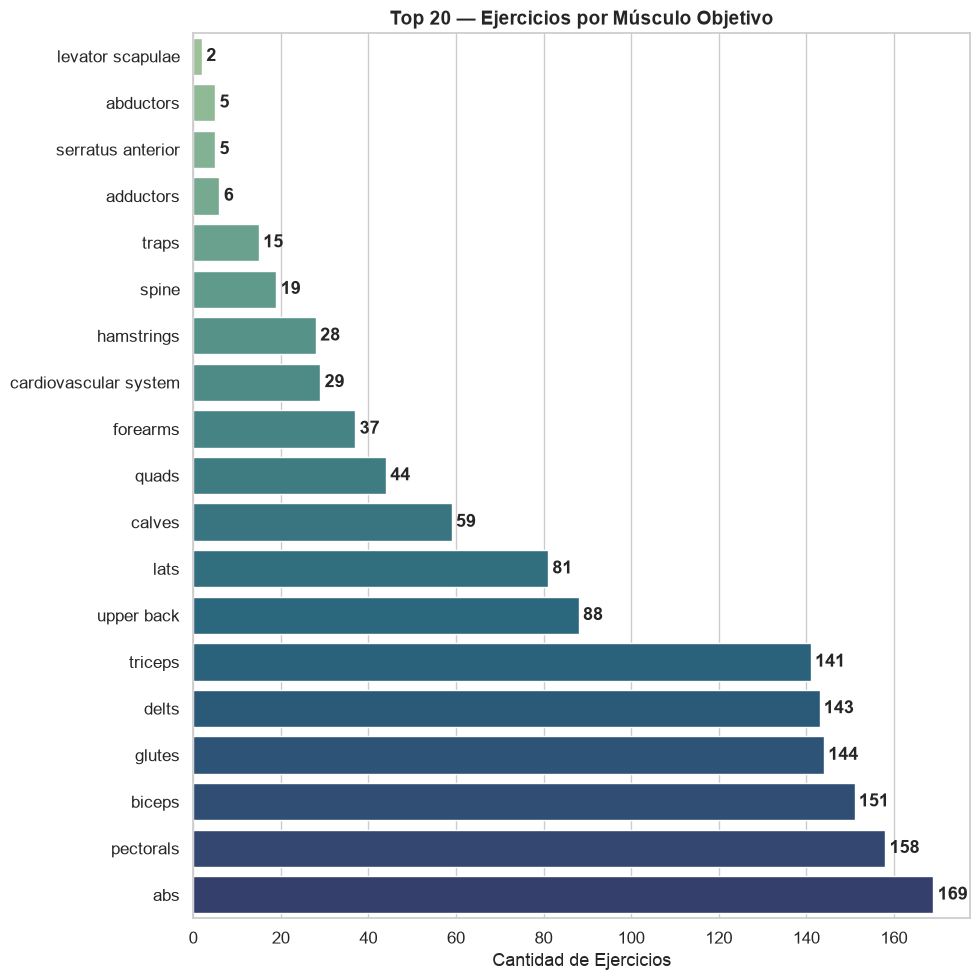

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))

target_counts = (
    clean_df.drop_duplicates(subset=["id"])
    .groupby("target", as_index=False)
    .agg(count=("id", "nunique"))
    .sort_values("count", ascending=True)
    .tail(20)
)

sns.barplot(
    data=target_counts,
    x="count",
    y="target",
    hue="target",
    palette="crest",
    legend=False,
    ax=ax,
)

for i, (_, row) in enumerate(target_counts.iterrows()):
    ax.text(row["count"] + 1, i, str(row["count"]), va="center", fontweight="bold")

ax.set_title("Top 20 — Ejercicios por Músculo Objetivo", fontsize=14, fontweight="bold")
ax.set_xlabel("Cantidad de Ejercicios")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 6. Heatmap — Body Part × Equipment

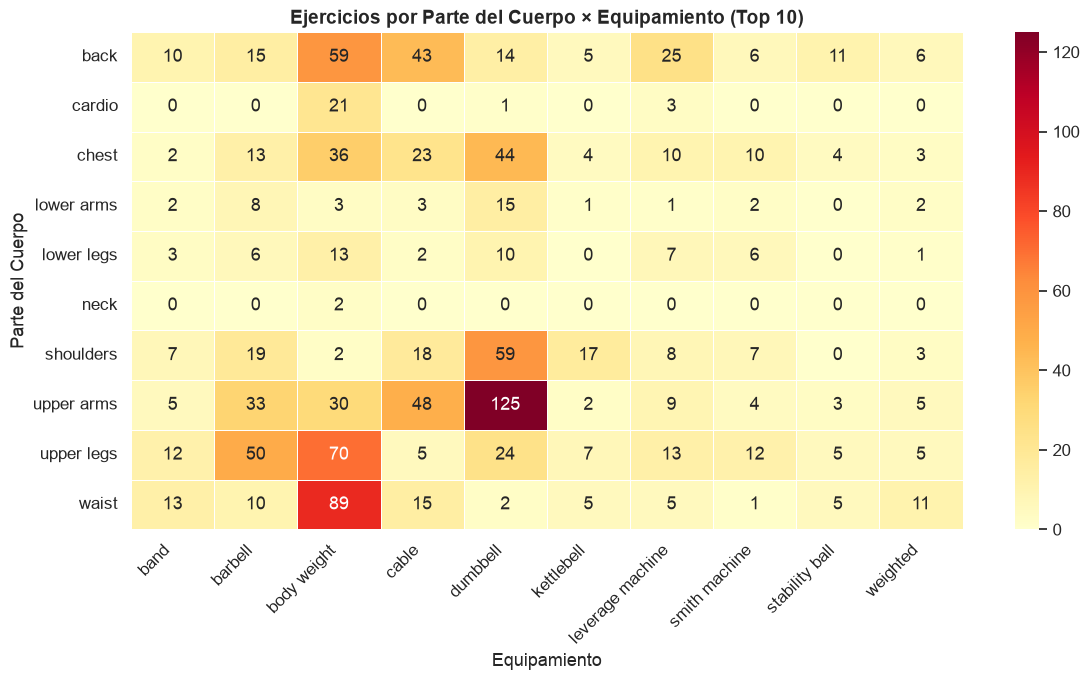

In [9]:
# Tomar solo los top 10 equipamientos para legibilidad
top_equip = (
    clean_df.drop_duplicates(subset=["id"])
    ["equipment"].value_counts().head(10).index.tolist()
)

heatmap_df = (
    clean_df.drop_duplicates(subset=["id"])
    .query("equipment in @top_equip")
    .groupby(["body_part", "equipment"])
    .agg(count=("id", "nunique"))
    .reset_index()
    .pivot(index="body_part", columns="equipment", values="count")
    .fillna(0)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
)
ax.set_title(
    "Ejercicios por Parte del Cuerpo × Equipamiento (Top 10)",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Equipamiento")
ax.set_ylabel("Parte del Cuerpo")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7. Músculos secundarios más frecuentes

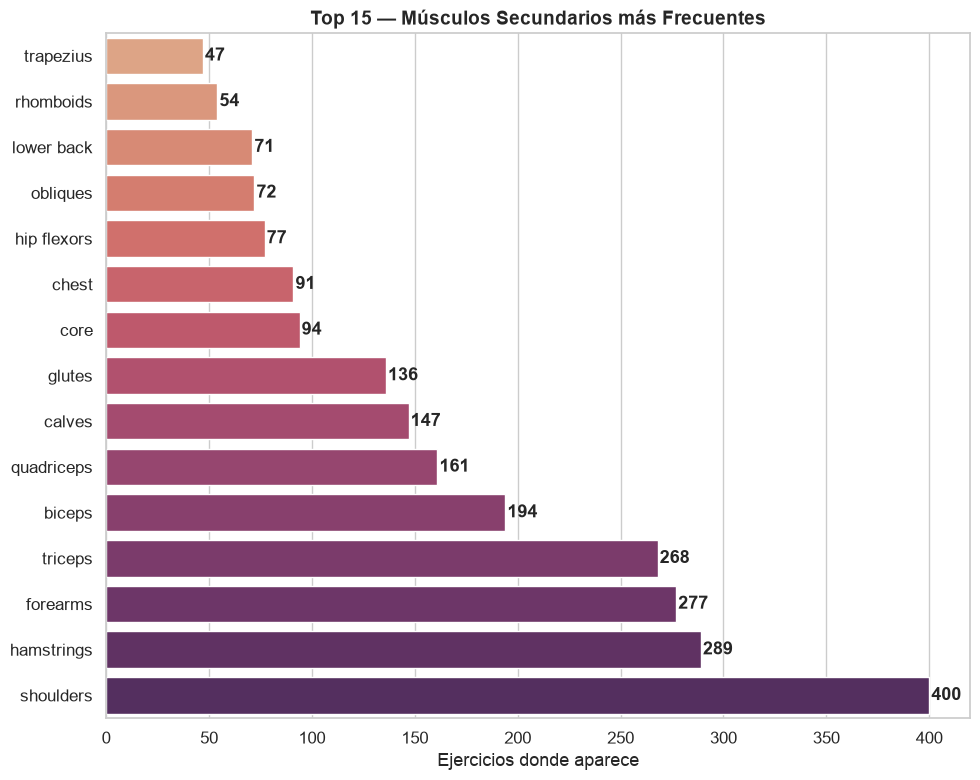

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

sec_counts = (
    clean_df.dropna(subset=["secondary_muscle"])
    .groupby("secondary_muscle", as_index=False)
    .agg(count=("id", "nunique"))
    .sort_values("count", ascending=True)
    .tail(15)
)

sns.barplot(
    data=sec_counts,
    x="count",
    y="secondary_muscle",
    hue="secondary_muscle",
    palette="flare",
    legend=False,
    ax=ax,
)

for i, (_, row) in enumerate(sec_counts.iterrows()):
    ax.text(row["count"] + 1, i, str(row["count"]), va="center", fontweight="bold")

ax.set_title(
    "Top 15 — Músculos Secundarios más Frecuentes",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Ejercicios donde aparece")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

---

# Parte II — IE3: Análisis Exploratorio Diagnóstico y Calidad de Datos

Las secciones anteriores describen la **composición categórica** del catálogo.
A partir de aquí se aborda el diagnóstico cuantitativo exigido por el IE3:
detección de outliers por rango intercuartílico, análisis de forma de las
distribuciones y auditoría de multicolinealidad.

## 8. Tabla analítica cuantitativa

El dataset limpio de la sección 1 está a grano **ejercicio × músculo secundario**
(por el `explode`), lo que inflaría cualquier estadístico univariado. Para el EDA
se usa `intermediate_exercise_features`, generado por el nodo
`build_exercise_features`, que está a grano **1 fila = 1 ejercicio**.

> **Correcciones aplicadas sobre la versión preliminar del equipo.**
> Durante la revisión se detectaron y corrigieron tres defectos:
>
> 1. **`musculo_primario` estaba invertido.** Se derivaba de `muscle_group`,
>    pero se verificó que ese campo está contenido en `secondary_muscles` en el
>    **100 % de los 1.324 registros**: es un sinergista, no el agonista. El
>    músculo primario real es `target`. Mantener el error habría invertido las
>    aristas primario/sinergista del futuro grafo biomecánico.
> 2. **`id` se corrompía al serializar a CSV.** Pandas lo reinterpretaba como
>    entero (`"0001"` → `1`), rompiendo la llave hacia `gif_url` y `media_id`
>    (`videos/0001-2gPfomN.gif`), que es la entrada de la fase cinemática.
>    Ahora se fuerza a texto con relleno de ceros.
> 3. **`n_musculos_total` sobrecontaba.** Se calculaba como `1 + len(secundarios)`,
>    lo que suma dos veces el músculo objetivo cuando éste también figura como
>    secundario. Ahora se deduplica el conjunto `{target} ∪ secundarios`.
>
> Además, la capa intermedia se persiste en **Parquet** y descarta los diccionarios
> de instrucciones en 10 idiomas: **1,0 MB en memoria frente a 17,0 MB** de la
> versión en CSV, en línea con la restricción FinOps del proyecto.

In [11]:
features = catalog.load("intermediate_exercise_features")

print(f"Grano: 1 fila = 1 ejercicio → {features.shape[0]} filas × {features.shape[1]} columnas")
print(f"Huella en memoria: {features.memory_usage(deep=True).sum()/1e6:.2f} MB")
print(f"Llave 'id' preservada como texto: {features['id'].dtype} → {features['id'].iloc[0]!r}")

features[["id", "name", "musculo_primario", "musculo_sinergista",
          "n_pasos", "n_palabras", "n_musculos_total"]].head()

[09/08/26 21:54:39] INFO     Loading data from intermediate_exercise_features                  ]8;id=10399775;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=10399776;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\
                             (ParquetDataset)...                                                                   

Grano: 1 fila = 1 ejercicio → 1324 filas × 21 columnas
Huella en memoria: 1.04 MB
Llave 'id' preservada como texto: str → '0001'


,id,name,musculo_primario,musculo_sinergista,n_pasos,n_palabras,n_musculos_total
0,0001,3/4 sit-up,abs,hip flexors,5,83,3
1,0002,45° side bend,abs,obliques,5,73,2
2,0003,air bike,abs,hip flexors,5,80,2
3,1512,all fours squad stretch,quads,hamstrings,5,65,3
4,0006,alternate heel touchers,abs,obliques,5,68,2


In [12]:
# Variables cuantitativas sobre las que opera todo el EDA diagnóstico
from gym_exercises.pipelines.data_understanding.nodes import VARIABLES_CUANTITATIVAS

CUANTI = VARIABLES_CUANTITATIVAS
print(f"{len(CUANTI)} variables cuantitativas derivadas:\n")
for v in CUANTI:
    print(f"  • {v}")

features[CUANTI].describe().T.round(2)

10 variables cuantitativas derivadas:

  • n_pasos
  • n_palabras
  • n_caracteres
  • palabras_por_paso
  • n_palabras_paso_max
  • n_palabras_nombre
  • n_musculos_secundarios
  • n_musculos_total
  • frecuencia_equipamiento
  • frecuencia_musculo_primario


,count,mean,std,min,25%,50%,75%,max
n_pasos,1324.0,5.82,1.08,4.0,5.0,6.0,6.0,11.00
n_palabras,1324.0,87.96,18.39,34.0,75.0,86.0,98.0,172.00
n_caracteres,1324.0,514.97,105.89,213.0,442.0,503.5,576.0,990.00
palabras_por_paso,1324.0,15.18,2.16,8.2,13.8,15.0,16.5,24.33
n_palabras_paso_max,1324.0,22.07,3.77,11.0,20.0,22.0,24.0,39.00
n_palabras_nombre,1324.0,4.22,1.65,1.0,3.0,4.0,5.0,12.00
n_musculos_secundarios,1324.0,1.95,0.73,1.0,1.0,2.0,2.0,6.00
n_musculos_total,1324.0,2.95,0.73,1.0,2.0,3.0,3.0,7.00
frecuencia_equipamiento,1324.0,194.38,117.29,1.0,81.0,157.0,294.0,325.00
frecuencia_musculo_primario,1324.0,121.44,47.72,2.0,88.0,143.0,151.0,169.00


### 8.1 Diccionario de variables derivadas

| Variable | Definición | Sentido analítico |
|---|---|---|
| `n_pasos` | Nº de pasos de la instrucción en español | Complejidad procedimental |
| `n_palabras` | Nº de palabras del texto completo | Volumen de instrucción |
| `n_caracteres` | Longitud en caracteres | Volumen de instrucción |
| `palabras_por_paso` | `n_palabras / n_pasos` | Densidad descriptiva por paso |
| `n_palabras_paso_max` | Longitud del paso más extenso | Punto de máxima carga cognitiva |
| `n_palabras_nombre` | Palabras en el nombre del ejercicio | Especificidad de la nomenclatura |
| `n_musculos_secundarios` | `len(secondary_muscles)` | Reclutamiento sinergista |
| `n_musculos_total` | `{target} ∪ secundarios` (deduplicado) | Complejidad biomecánica |
| `frecuencia_equipamiento` | Nº de ejercicios que comparten el equipamiento | Accesibilidad / sesgo de oferta |
| `frecuencia_musculo_primario` | Nº de ejercicios por músculo objetivo | Cobertura del músculo |

---

## 9. Detección de outliers — Rango Intercuartílico (IQR)

Se aplica el **criterio de Tukey** sobre cada variable cuantitativa:

$$IQR = Q_3 - Q_1$$

$$\text{Límite inferior} = Q_1 - 1.5 \times IQR \qquad \text{Límite superior} = Q_3 + 1.5 \times IQR$$

Todo valor fuera de ese intervalo se marca como atípico. Se eligió el IQR sobre
el z-score porque es **robusto**: los cuartiles no se ven arrastrados por los
propios valores extremos, y las variables aquí analizadas no son normales
(ver sección 10).

In [13]:
outliers = catalog.load("outliers_iqr_report")
outliers.style.format(precision=2).background_gradient(
    subset=["pct_outliers"], cmap="OrRd"
).set_caption("Criterio de Tukey (k = 1.5) por variable cuantitativa")

                    INFO     Loading data from outliers_iqr_report (CSVDataset)...             ]8;id=10399781;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=10399782;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

,variable,Q1,mediana,Q3,IQR,limite_inferior,limite_superior,n_outliers,pct_outliers,n_outliers_inferiores,n_outliers_superiores
0,n_pasos,5.00,6.00,6.00,1.00,3.50,7.50,92,6.95,0,92
1,n_palabras,75.00,86.00,98.00,23.00,40.50,132.50,26,1.96,1,25
2,n_caracteres,442.00,503.50,576.00,134.00,241.00,777.00,26,1.96,2,24
3,palabras_por_paso,13.80,15.00,16.50,2.70,9.75,20.55,20,1.51,5,15
4,n_palabras_paso_max,20.00,22.00,24.00,4.00,14.00,30.00,43,3.25,9,34
5,n_palabras_nombre,3.00,4.00,5.00,2.00,0.00,8.00,16,1.21,0,16
6,n_musculos_secundarios,1.00,2.00,2.00,1.00,-0.50,3.50,32,2.42,0,32
7,n_musculos_total,2.00,3.00,3.00,1.00,0.50,4.50,32,2.42,0,32
8,frecuencia_equipamiento,81.00,157.00,294.00,213.00,-238.50,613.50,0,0.00,0,0
9,frecuencia_musculo_primario,88.00,143.00,151.00,63.00,-6.50,245.50,0,0.00,0,0


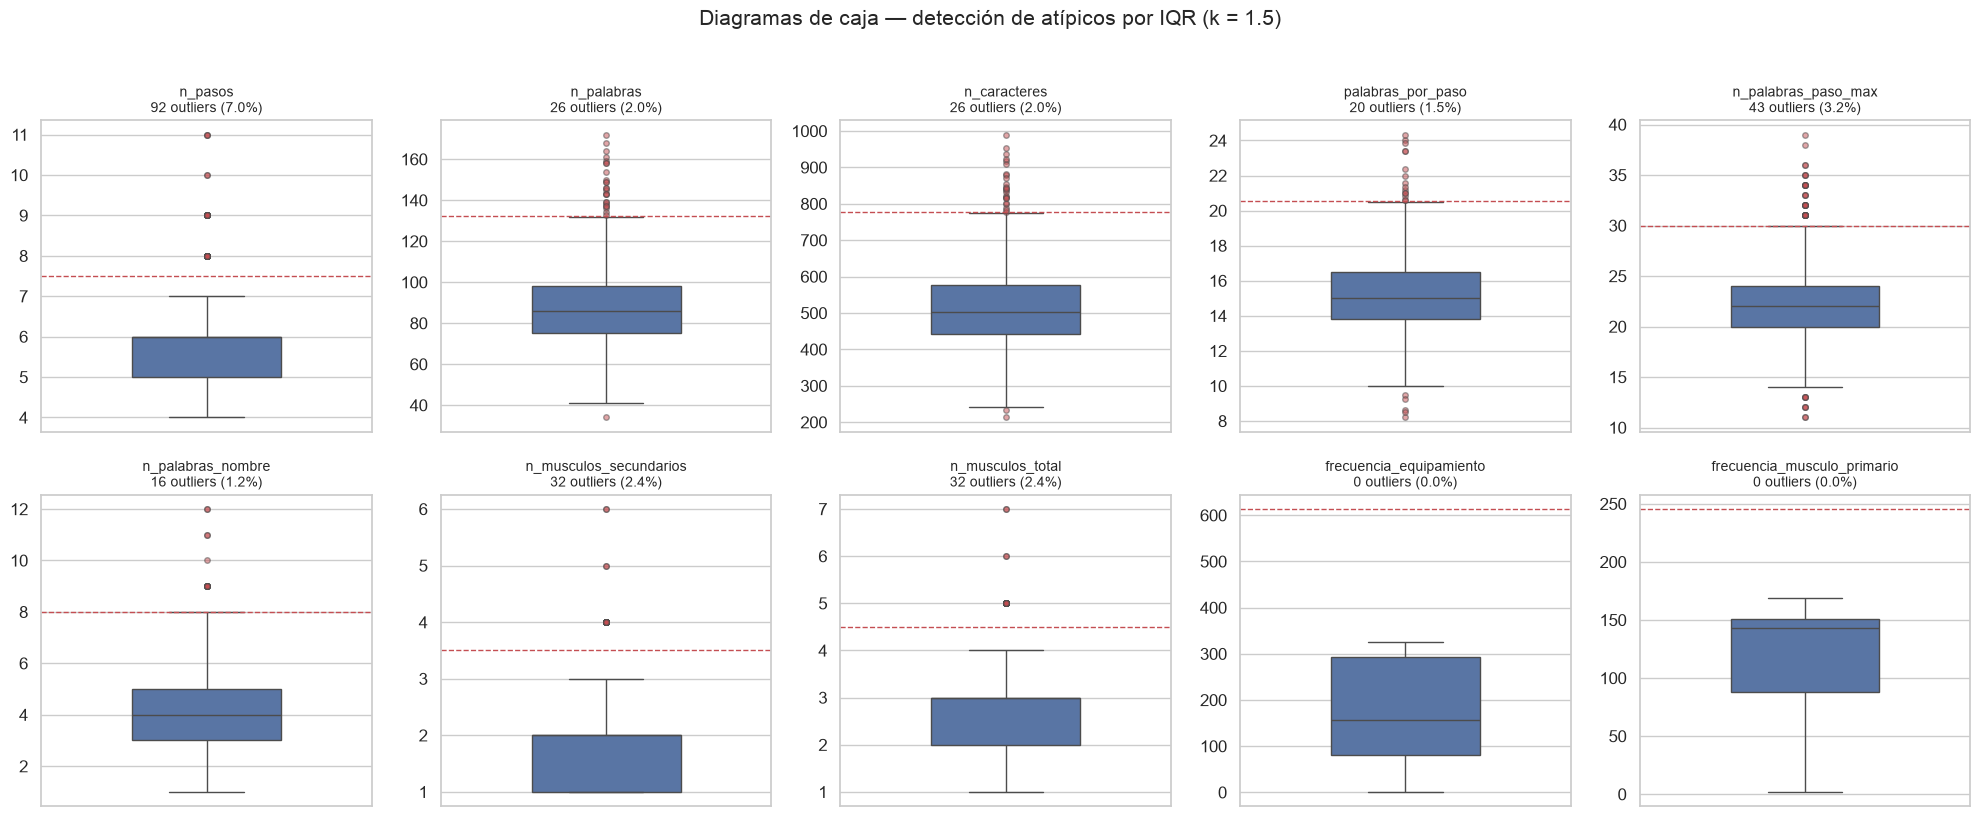

In [14]:
# ── Boxplots: visualización de los bigotes y los puntos atípicos ─────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, var in zip(axes.ravel(), CUANTI):
    sns.boxplot(y=features[var], ax=ax, color="#4C72B0", width=0.45,
                flierprops=dict(marker="o", markersize=4,
                                markerfacecolor="#C44E52", alpha=0.5))
    fila = outliers.loc[outliers["variable"] == var].iloc[0]
    ax.set_title(f"{var}\n{int(fila['n_outliers'])} outliers "
                 f"({fila['pct_outliers']:.1f}%)", fontsize=10)
    ax.set_ylabel("")
    ax.axhline(fila["limite_superior"], ls="--", lw=1, color="#C44E52")

fig.suptitle("Diagramas de caja — detección de atípicos por IQR (k = 1.5)",
             fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig("data/08_reporting/figures/boxplots_iqr.png", dpi=120, bbox_inches="tight")
plt.show()

In [15]:
# ── ¿Quiénes son los ejercicios atípicos? ────────────────────────────────
q1, q3 = features["n_pasos"].quantile(0.25), features["n_pasos"].quantile(0.75)
lim_sup = q3 + 1.5 * (q3 - q1)

print(f"n_pasos → Q1={q1:.0f}, Q3={q3:.0f}, IQR={q3-q1:.0f}, límite superior={lim_sup:.1f}\n")
print("Ejercicios con más pasos de los esperados (top 10):")
features.nlargest(10, "n_pasos")[
    ["id", "name", "body_part", "equipment", "n_pasos", "n_musculos_total"]
]

n_pasos → Q1=5, Q3=6, IQR=1, límite superior=7.5

Ejercicios con más pasos de los esperados (top 10):


,id,name,body_part,equipment,n_pasos,n_musculos_total
648,1330,dumbbell reverse grip incline bench one arm row,back,dumbbell,11,3
701,3560,dumbbell standing alternate hammer curl and press,upper arms,dumbbell,11,3
1188,1434,smith low bar squat,upper legs,smith machine,11,4
403,0236,cable standing twist row (v-bar),back,cable,10,3
1182,0755,smith hack squat,upper legs,smith machine,10,4
53,3116,band fixed back underhand pulldown,back,band,9,4
57,0979,band horizontal pallof press,waist,band,9,3
162,0072,barbell prone incline curl,upper arms,barbell,9,2
298,0170,cable incline fly (on stability ball),chest,cable,9,3
327,1633,cable one arm preacher curl,upper arms,cable,9,2


### 9.1 Interpretación y decisión de conservación

Se detectaron **287 valores atípicos** repartidos en 8 de las 10 variables.
La decisión, variable por variable:

| Variable | % atípicos | Decisión | Justificación |
|---|---|---|---|
| `n_pasos` | 6,95 % | **Conservar** | Son ejercicios genuinamente complejos (movimientos compuestos y olímpicos que exigen más de 7 pasos). No son errores de captura. |
| `n_palabras` / `n_caracteres` | 1,96 % | **Conservar** | Correlacionan con `n_pasos`; describen el mismo fenómeno real de complejidad. |
| `palabras_por_paso` | 1,51 % | **Conservar, marcar** | Los 5 atípicos inferiores son pasos telegráficos: candidatos a revisión editorial, no a eliminación. |
| `n_palabras_paso_max` | 3,25 % | **Conservar** | Señala pasos con alta carga cognitiva; es información útil para la app, no ruido. |
| `n_musculos_secundarios` / `n_musculos_total` | 2,42 % | **Conservar** | Ejercicios con 5–7 músculos son compuestos reales (peso muerto, cargadas). Eliminarlos empobrecería justo la parte más informativa del grafo biomecánico. |
| `frecuencia_equipamiento` / `frecuencia_musculo_primario` | 0 % | — | Sin atípicos: la dispersión es tan amplia que los bigotes cubren todo el rango. |

> **Criterio general: no se elimina ningún registro.** Los atípicos detectados son
> *valores extremos legítimos*, no errores de medición. Como el dataset no tiene
> nulos ni duplicados, el IQR aquí funciona como **instrumento de caracterización**
> y no de limpieza. Eliminarlos sesgaría el catálogo hacia ejercicios simples,
> que es exactamente el sesgo que el IE4 busca denunciar.

---

## 10. Histogramas con KDE y análisis de forma

Se superpone la estimación de densidad por kernel (KDE) al histograma para
evaluar la forma de cada distribución, junto con la **asimetría** (*skewness*)
y la **curtosis** de Fisher.

                    INFO     Loading data from shape_statistics_report (CSVDataset)...         ]8;id=10399787;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=10399788;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

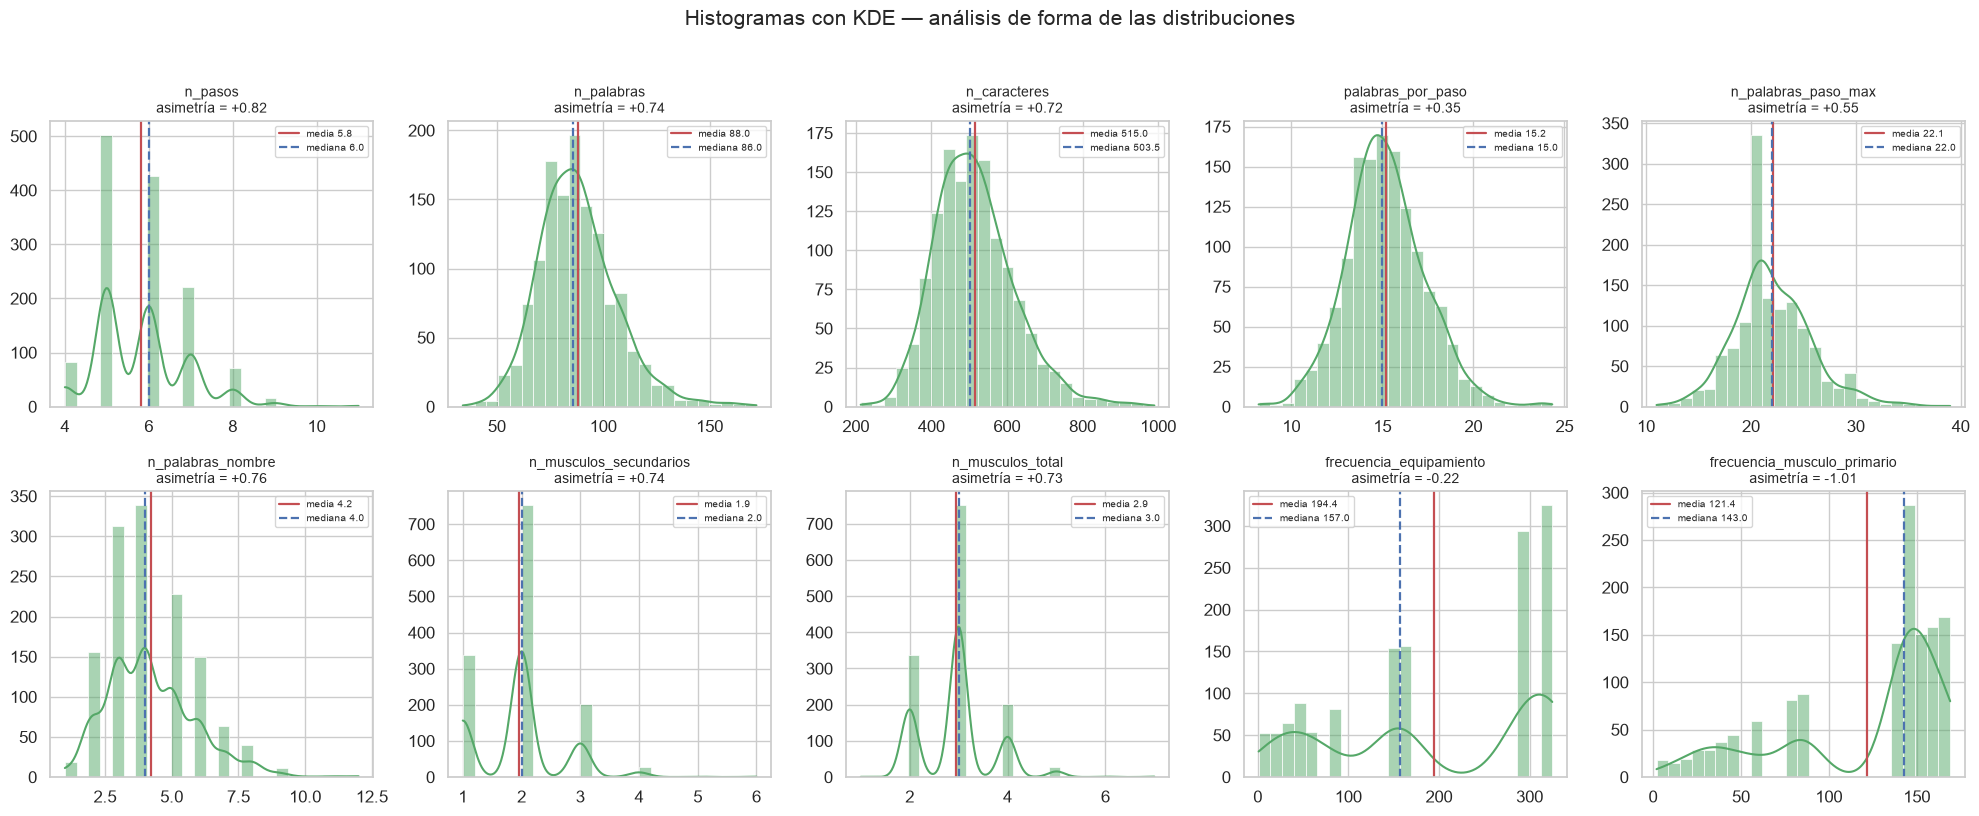

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
shape_stats = catalog.load("shape_statistics_report").set_index("variable")

for ax, var in zip(axes.ravel(), CUANTI):
    sns.histplot(features[var], kde=True, ax=ax, color="#55A868",
                 edgecolor="white", linewidth=0.5, bins=25)
    media, mediana = features[var].mean(), features[var].median()
    ax.axvline(media, color="#C44E52", ls="-", lw=1.6, label=f"media {media:.1f}")
    ax.axvline(mediana, color="#4C72B0", ls="--", lw=1.6, label=f"mediana {mediana:.1f}")
    asim = shape_stats.loc[var, "asimetria"]
    ax.set_title(f"{var}\nasimetría = {asim:+.2f}", fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.legend(fontsize=7)

fig.suptitle("Histogramas con KDE — análisis de forma de las distribuciones",
             fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig("data/08_reporting/figures/histogramas_kde.png", dpi=120, bbox_inches="tight")
plt.show()

In [17]:
stats = catalog.load("shape_statistics_report")
stats.style.format(precision=3).background_gradient(
    subset=["asimetria"], cmap="coolwarm", vmin=-1.5, vmax=1.5
).set_caption("Estadísticos de forma — tendencia central, dispersión y sesgo")

[09/08/26 21:54:40] INFO     Loading data from shape_statistics_report (CSVDataset)...         ]8;id=10399793;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=10399794;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

,variable,n,media,mediana,desv_std,cv,minimo,maximo,asimetria,curtosis,forma
0,n_pasos,1324,5.823,6.000,1.079,0.185,4.000,11.000,0.825,1.175,sesgo positivo moderado
1,n_palabras,1324,87.958,86.000,18.387,0.209,34.000,172.000,0.743,1.449,sesgo positivo moderado
2,n_caracteres,1324,514.971,503.500,105.887,0.206,213.000,990.000,0.721,1.143,sesgo positivo moderado
3,palabras_por_paso,1324,15.183,15.000,2.159,0.142,8.200,24.333,0.354,0.787,aproximadamente simétrica
4,n_palabras_paso_max,1324,22.069,22.000,3.767,0.171,11.000,39.000,0.553,1.161,sesgo positivo moderado
5,n_palabras_nombre,1324,4.217,4.000,1.655,0.392,1.000,12.000,0.763,0.898,sesgo positivo moderado
6,n_musculos_secundarios,1324,1.949,2.000,0.726,0.372,1.000,6.000,0.742,1.707,sesgo positivo moderado
7,n_musculos_total,1324,2.948,3.000,0.728,0.247,1.000,7.000,0.727,1.701,sesgo positivo moderado
8,frecuencia_equipamiento,1324,194.376,157.000,117.285,0.603,1.000,325.000,-0.223,-1.550,aproximadamente simétrica
9,frecuencia_musculo_primario,1324,121.438,143.000,47.725,0.393,2.000,169.000,-1.006,-0.428,sesgo negativo fuerte


### 10.1 Lectura del análisis de forma

**Sesgo positivo generalizado.** Siete de las diez variables presentan asimetría
positiva moderada (entre +0,55 y +0,83): `n_pasos`, `n_palabras`, `n_caracteres`,
`n_palabras_paso_max`, `n_palabras_nombre`, `n_musculos_secundarios` y
`n_musculos_total`. En todas, **media > mediana**, y la cola derecha es la que
concentra los atípicos del IQR.

La interpretación de negocio es directa: **el catálogo está compuesto
mayoritariamente por ejercicios simples y cortos**, con una minoría de movimientos
compuestos que estiran la distribución hacia la derecha. La moda de `n_musculos_total`
es 3 y la de `n_pasos` es 6.

**El caso anómalo: `frecuencia_musculo_primario` (asimetría −1,01, curtosis −0,43).**
Es la única variable con sesgo negativo fuerte y, además, platicúrtica. Esto
significa que la mayoría de los ejercicios apuntan a músculos **muy** cubiertos
(abs, pectorals, biceps rondan los 150–169 ejercicios cada uno), mientras que una
cola izquierda delgada corresponde a músculos casi huérfanos: `levator scapulae`
(2 ejercicios), `abductors` (5), `serratus anterior` (5), `adductors` (6).

> Este hallazgo es la **evidencia estadística del sesgo de muestreo** que se
> desarrolla en la sección 12 (IE4). No es un problema de calidad del dato:
> es un problema de **cobertura clínica**.

**`frecuencia_equipamiento` (curtosis −1,55).** Distribución fuertemente bimodal:
o el equipamiento es muy común, o es marginal. No hay término medio.

---

## 11. Matriz de correlación de Pearson y auditoría de multicolinealidad

El coeficiente de Pearson mide la asociación **lineal** entre pares de variables:

$$r_{xy} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2}\sqrt{\sum (y_i - \bar{y})^2}}$$

Su propósito aquí es **auditar redundancia antes de cualquier modelado
posterior**: pares con $|r| > 0.9$ aportan la misma información y deben
depurarse para no inflar artificialmente el peso de un fenómeno.

                    INFO     Loading data from correlation_matrix_report (CSVDataset)...       ]8;id=10399799;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=10399800;file:///Users/unk/Desktop/proyecto_ejercicios/.venv/lib/python3.14/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

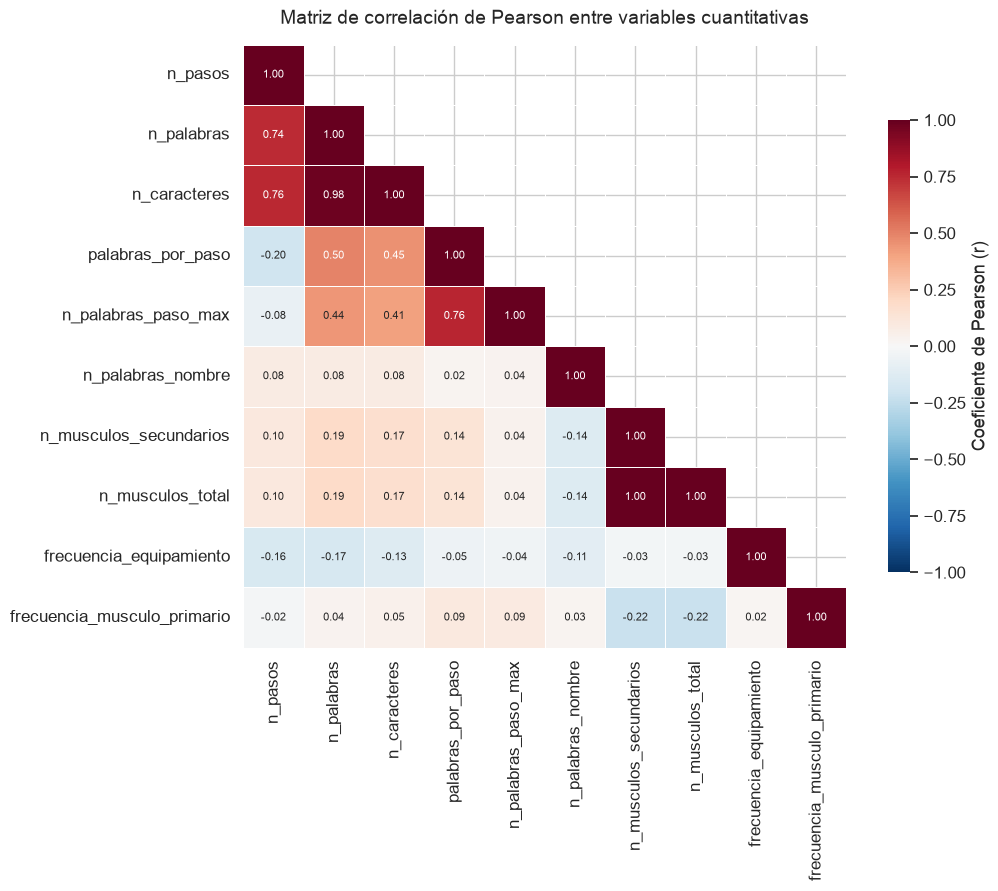

In [18]:
corr = catalog.load("correlation_matrix_report").set_index("variable")

fig, ax = plt.subplots(figsize=(11, 9))
mascara = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, mask=mascara, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.75, "label": "Coeficiente de Pearson (r)"},
            annot_kws={"size": 8}, ax=ax)

ax.set_title("Matriz de correlación de Pearson entre variables cuantitativas",
             fontsize=14, pad=15)
ax.set_xlabel(""); ax.set_ylabel("")
fig.tight_layout()
fig.savefig("data/08_reporting/figures/matriz_correlacion.png", dpi=120, bbox_inches="tight")
plt.show()

In [19]:
# ── Auditoría formal de multicolinealidad ────────────────────────────────
triangulo = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

pares = triangulo.stack().rename("r").reset_index()
pares.columns = ["variable_A", "variable_B", "r"]
pares["abs_r"] = pares["r"].abs()
pares = pares.sort_values("abs_r", ascending=False)

print("Pares con |r| > 0.9 — REDUNDANCIA CRÍTICA:")
print(pares.loc[pares["abs_r"] > 0.9, ["variable_A", "variable_B", "r"]].to_string(index=False))
print("\nTop 8 asociaciones por magnitud:")
pares.head(8)[["variable_A", "variable_B", "r"]].round(3)

Pares con |r| > 0.9 — REDUNDANCIA CRÍTICA:
            variable_A       variable_B      r
n_musculos_secundarios n_musculos_total 0.9986
            n_palabras     n_caracteres 0.9813

Top 8 asociaciones por magnitud:


,variable_A,variable_B,r
67,n_musculos_secundarios,n_musculos_total,0.999
12,n_palabras,n_caracteres,0.981
34,palabras_por_paso,n_palabras_paso_max,0.762
2,n_pasos,n_caracteres,0.756
1,n_pasos,n_palabras,0.744
13,n_palabras,palabras_por_paso,0.497
23,n_caracteres,palabras_por_paso,0.454
14,n_palabras,n_palabras_paso_max,0.442


### 11.1 Hallazgos de la auditoría

**Dos pares redundantes que deben depurarse:**

| Par | *r* | Diagnóstico |
|---|---|---|
| `n_musculos_secundarios` ↔ `n_musculos_total` | **0,999** | Redundancia casi perfecta, y es esperable: `n_musculos_total = n_musculos_secundarios + 1` salvo en los 2 registros donde el músculo objetivo también figura como secundario. **Conservar solo `n_musculos_total`** (deduplicado y semánticamente correcto). |
| `n_palabras` ↔ `n_caracteres` | **0,981** | Miden el mismo volumen textual en unidades distintas. **Conservar `n_palabras`**, más interpretable. |

**Asociaciones informativas (no redundantes):**

- `palabras_por_paso` ↔ `n_palabras_paso_max` (**0,76**): las instrucciones densas
  lo son de forma pareja; no hay un paso largo aislado entre pasos cortos.
- `n_pasos` ↔ `n_palabras` (**0,74**): más pasos implica más texto, pero la
  relación no es determinista.
- `n_pasos` ↔ `palabras_por_paso` (**−0,20**): correlación **negativa**. Cuando un
  ejercicio se descompone en más pasos, cada paso individual se vuelve más breve.
  Es un hallazgo de diseño editorial: el catálogo mantiene aproximadamente
  constante el esfuerzo cognitivo por paso.

**Independencia relevante:** la complejidad muscular (`n_musculos_total`) apenas
correlaciona con la complejidad textual (`n_pasos`, *r* = 0,10). Es decir, **la
extensión de la instrucción no predice la exigencia biomecánica del movimiento**.
Un peso muerto recluta 5 músculos y se describe en 5 pasos. Para el modelo de
recomendación esto es una buena noticia: son dos ejes de información
independientes, y ambos aportan señal.

`n_musculos_secundarios` ↔ `frecuencia_musculo_primario` (**−0,22**): los músculos
mejor cubiertos del catálogo tienden a trabajarse de forma aislada.

---

## 12. IE4 — Evidencia cuantitativa del sesgo de muestreo

El análisis ético del `README.md` se apoya en las siguientes mediciones. Se usa
el **coeficiente de Gini** sobre la distribución de frecuencias como índice de
concentración (0 = cobertura perfectamente uniforme, 1 = concentración total).

In [20]:
def gini(x):
    """Coeficiente de Gini sobre un vector de frecuencias."""
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) / (n * np.sum(x))) - (n + 1) / n

freq_equip = features["equipment"].value_counts()
freq_musc = features["musculo_primario"].value_counts()

print(f"Gini equipamiento     : {gini(freq_equip.values):.3f}  ({features.equipment.nunique()} categorías)")
print(f"Gini músculo primario : {gini(freq_musc.values):.3f}  ({features.musculo_primario.nunique()} categorías)")
print(f"\nTop-3 equipamientos concentran: {freq_equip.head(3).sum()/len(features)*100:.1f}% del catálogo")
print(f"Equipamientos con <10 ejercicios: {(freq_equip < 10).sum()} categorías "
      f"= solo {freq_equip[freq_equip < 10].sum()} ejercicios ({freq_equip[freq_equip<10].sum()/len(features)*100:.1f}%)")

# Agrupación por contexto de uso
GIMNASIO = {"dumbbell", "barbell", "cable", "leverage machine", "smith machine",
            "ez barbell", "weighted", "olympic barbell", "trap bar", "sled machine"}
REHAB = {"band", "stability ball", "assisted", "medicine ball", "wheel roller", "roller"}

contexto = np.select(
    [features["equipment"].isin(GIMNASIO),
     features["equipment"] == "body weight",
     features["equipment"].isin(REHAB)],
    ["Gimnasio tradicional", "Peso corporal / calistenia", "Rehabilitación / funcional"],
    default="Cardio / otros",
)
resumen = pd.Series(contexto).value_counts()
print("\n── Cobertura por contexto de entrenamiento ──")
for k, v in resumen.items():
    print(f"  {k:<30} {v:>5} ({v/len(features)*100:>5.1f}%)")

Gini equipamiento     : 0.737  (28 categorías)
Gini músculo primario : 0.478  (19 categorías)

Top-3 equipamientos concentran: 58.6% del catálogo
Equipamientos con <10 ejercicios: 13 categorías = solo 30 ejercicios (2.3%)

── Cobertura por contexto de entrenamiento ──
  Gimnasio tradicional             811 ( 61.3%)
  Peso corporal / calistenia       325 ( 24.5%)
  Rehabilitación / funcional       120 (  9.1%)
  Cardio / otros                    68 (  5.1%)


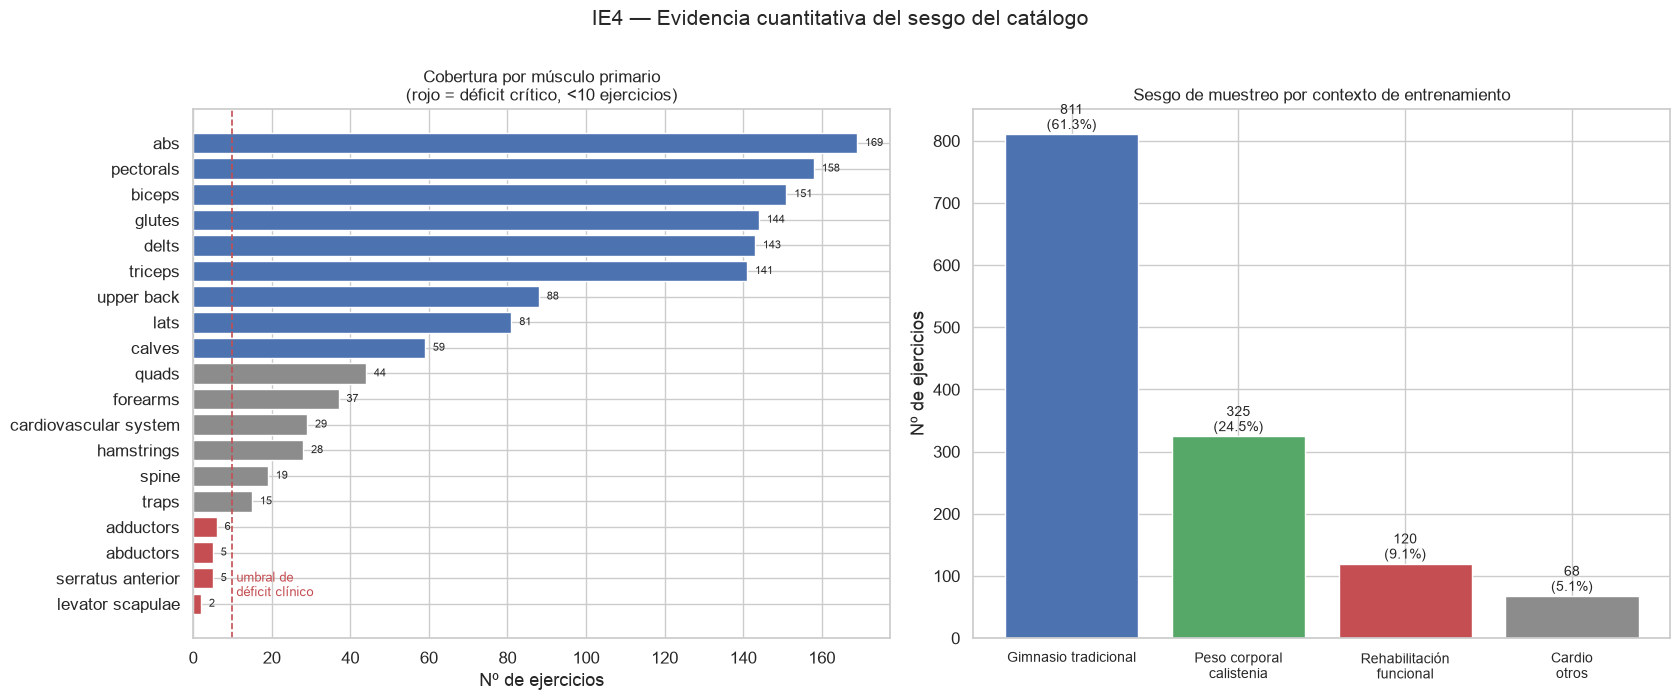

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7))

# ── Izquierda: cobertura por músculo primario ────────────────────────────
orden = freq_musc.sort_values()
colores = ["#C44E52" if v < 10 else "#8C8C8C" if v < 50 else "#4C72B0" for v in orden.values]
ax1.barh(orden.index, orden.values, color=colores)
ax1.axvline(10, ls="--", color="#C44E52", lw=1.2)
ax1.text(11, 0.3, "umbral de\ndéficit clínico", color="#C44E52", fontsize=9)
ax1.set_title("Cobertura por músculo primario\n(rojo = déficit crítico, <10 ejercicios)",
              fontsize=12)
ax1.set_xlabel("Nº de ejercicios")
for i, v in enumerate(orden.values):
    ax1.text(v + 2, i, str(v), va="center", fontsize=8)

# ── Derecha: concentración por contexto de uso ───────────────────────────
resumen_ord = resumen.reindex(["Gimnasio tradicional", "Peso corporal / calistenia",
                               "Rehabilitación / funcional", "Cardio / otros"])
barras = ax2.bar(range(len(resumen_ord)), resumen_ord.values,
                 color=["#4C72B0", "#55A868", "#C44E52", "#8C8C8C"])
ax2.set_xticks(range(len(resumen_ord)))
ax2.set_xticklabels([t.replace(" / ", "\n") for t in resumen_ord.index], fontsize=10)
ax2.set_title("Sesgo de muestreo por contexto de entrenamiento", fontsize=12)
ax2.set_ylabel("Nº de ejercicios")
for b, v in zip(barras, resumen_ord.values):
    ax2.text(b.get_x() + b.get_width()/2, v + 8, f"{v}\n({v/len(features)*100:.1f}%)",
             ha="center", fontsize=10)

fig.suptitle("IE4 — Evidencia cuantitativa del sesgo del catálogo", fontsize=15, y=1.00)
fig.tight_layout()
fig.savefig("data/08_reporting/figures/sesgo_muestreo.png", dpi=120, bbox_inches="tight")
plt.show()

### 12.1 Lectura ética de la evidencia

1. **Concentración de equipamiento (Gini = 0,737).** Tres categorías —*body weight*,
   *dumbbell* y *cable*— concentran el **58,6 %** del catálogo, mientras que 13 de
   las 28 categorías suman apenas 30 ejercicios (2,3 %). El catálogo asume
   implícitamente **acceso a un gimnasio equipado**: el 61,3 % de los ejercicios
   requiere peso libre o máquinas.

2. **Déficit de rehabilitación.** Solo el **9,1 %** del catálogo usa material de
   trabajo funcional o asistido (bandas, balón de estabilidad, asistido). Un
   usuario en recuperación post-lesión, de tercera edad o sin acceso a gimnasio
   recibiría recomendaciones sistemáticamente inadecuadas.

3. **Músculos huérfanos.** Cuatro grupos musculares tienen menos de 10 ejercicios:
   `levator scapulae` (2), `abductors` (5), `serratus anterior` (5) y `adductors` (6).
   Es un déficit clínicamente relevante: abductores y aductores son centrales en
   la **estabilidad de cadera** y en la prevención de lesiones de rodilla. La
   funcionalidad de sustitución por lesión que el proyecto persigue tendría, hoy,
   un espacio de búsqueda casi vacío para esas articulaciones.

4. **Desbalance agonista/antagonista.** `quads` tiene 44 ejercicios frente a 28 de
   `hamstrings` (ratio 1,6:1). Un plan generado sin corregir esta proporción
   reforzaría el desbalance cuádriceps-isquiotibiales, un factor de riesgo
   documentado en lesiones de ligamento cruzado anterior.

5. **Ausencia de variables de estratificación.** El esquema **no incluye** campos
   de nivel de dificultad, mecánica (compuesto/aislado), tipo de fuerza
   (empuje/tracción) ni contraindicaciones. Sin esas variables es imposible
   auditar el sesgo por nivel del usuario, y ninguna imputación sería honesta:
   **la información no existe en la fuente**. Se documenta como limitación, no se
   inventa.

> **Implicación de diseño.** El sesgo no se corrige eliminando filas, sino
> **declarándolo** y aplicando reglas de seguridad en la capa de recomendación
> (sección 4 del `README.md`). Un modelo entrenado sobre este catálogo sin
> mitigación reproduciría la lógica del gimnasio comercial y excluiría a las
> poblaciones que más se beneficiarían de una guía biomecánica.

---

## 📝 Conclusiones del EDA

**Calidad estructural — excelente.**
1.324 ejercicios únicos, **0 nulos**, **0 duplicados** por `id`, esquema consistente
en las 15 columnas de origen y traducciones completas en 10 idiomas. No se requirió
imputación alguna.

**Composición del catálogo.**
Dominan `upper arms` (22,1 %) y `upper legs` (17,1 %); `neck` queda en 0,2 %.
El equipamiento más frecuente es *body weight* (24,5 %).

**Diagnóstico cuantitativo (IE3).**
- **287 atípicos** por criterio de Tukey en 8 de 10 variables. **Ninguno se elimina**:
  todos son valores extremos legítimos (ejercicios compuestos), no errores.
- **Sesgo positivo moderado** en 7 de 10 variables: el catálogo es mayoritariamente
  de ejercicios simples y cortos, con cola derecha de movimientos complejos.
- **Dos pares redundantes** (*r* = 0,999 y *r* = 0,981) identificados para depurar
  antes de modelar. La complejidad muscular y la textual son **ejes independientes**
  (*r* = 0,10), lo que valida usar ambos como señal.

**Riesgo ético principal (IE4).**
Gini de equipamiento **0,737** y cuatro grupos musculares con menos de 10 ejercicios.
El sesgo del catálogo es hacia la **hipertrofia en gimnasio equipado**, en desmedro
de rehabilitación, tercera edad y entrenamiento sin material.

**Estado de la fase.**
Cerradas las fases 1–3 de CRISP-DM (Comprensión del Negocio, Comprensión de los
Datos y Preparación). **No se entrena ningún modelo predictivo en esta entrega**,
en conformidad con el alcance de la EV1.